In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
import sys
print(sys.executable)

c:\Work\Blood Glucose predictor\Blood-glucose-prediction\venv\Scripts\python.exe


## Lets load the Diabetes Dataset

In [3]:
from sklearn.datasets import load_diabetes

boston = load_diabetes()

In [4]:
boston.keys()

dict_keys(['data', 'target', 'frame', 'DESCR', 'feature_names', 'data_filename', 'target_filename', 'data_module'])

In [5]:
## Lets check the description of the dataset
print(boston.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [6]:
print(boston.data)

[[ 0.03807591  0.05068012  0.06169621 ... -0.00259226  0.01990749
  -0.01764613]
 [-0.00188202 -0.04464164 -0.05147406 ... -0.03949338 -0.06833155
  -0.09220405]
 [ 0.08529891  0.05068012  0.04445121 ... -0.00259226  0.00286131
  -0.02593034]
 ...
 [ 0.04170844  0.05068012 -0.01590626 ... -0.01107952 -0.04688253
   0.01549073]
 [-0.04547248 -0.04464164  0.03906215 ...  0.02655962  0.04452873
  -0.02593034]
 [-0.04547248 -0.04464164 -0.0730303  ... -0.03949338 -0.00422151
   0.00306441]]


In [7]:
print(boston.target)

[151.  75. 141. 206. 135.  97. 138.  63. 110. 310. 101.  69. 179. 185.
 118. 171. 166. 144.  97. 168.  68.  49.  68. 245. 184. 202. 137.  85.
 131. 283. 129.  59. 341.  87.  65. 102. 265. 276. 252.  90. 100.  55.
  61.  92. 259.  53. 190. 142.  75. 142. 155. 225.  59. 104. 182. 128.
  52.  37. 170. 170.  61. 144.  52. 128.  71. 163. 150.  97. 160. 178.
  48. 270. 202. 111.  85.  42. 170. 200. 252. 113. 143.  51.  52. 210.
  65. 141.  55. 134.  42. 111.  98. 164.  48.  96.  90. 162. 150. 279.
  92.  83. 128. 102. 302. 198.  95.  53. 134. 144. 232.  81. 104.  59.
 246. 297. 258. 229. 275. 281. 179. 200. 200. 173. 180.  84. 121. 161.
  99. 109. 115. 268. 274. 158. 107.  83. 103. 272.  85. 280. 336. 281.
 118. 317. 235.  60. 174. 259. 178. 128.  96. 126. 288.  88. 292.  71.
 197. 186.  25.  84.  96. 195.  53. 217. 172. 131. 214.  59.  70. 220.
 268. 152.  47.  74. 295. 101. 151. 127. 237. 225.  81. 151. 107.  64.
 138. 185. 265. 101. 137. 143. 141.  79. 292. 178.  91. 116.  86. 122.
  72. 

In [8]:
print(boston.feature_names)

['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


## Preparing the dataset

In [9]:
dataset=pd.DataFrame(boston.data,columns=boston.feature_names)

In [10]:
dataset.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [11]:
dataset['Blood Glucose']=boston.target

In [12]:
dataset.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,Blood Glucose
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [13]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   age            442 non-null    float64
 1   sex            442 non-null    float64
 2   bmi            442 non-null    float64
 3   bp             442 non-null    float64
 4   s1             442 non-null    float64
 5   s2             442 non-null    float64
 6   s3             442 non-null    float64
 7   s4             442 non-null    float64
 8   s5             442 non-null    float64
 9   s6             442 non-null    float64
 10  Blood Glucose  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


In [14]:
## Summarizing the stats of data
dataset.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,Blood Glucose
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.268604e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


In [15]:
## Missing Valuees check
dataset.isnull().sum()

age              0
sex              0
bmi              0
bp               0
s1               0
s2               0
s3               0
s4               0
s5               0
s6               0
Blood Glucose    0
dtype: int64

In [16]:
## exploratory data analysis
## Correlation

dataset.corr()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,Blood Glucose
age,1.000000,0.173737,0.185085,0.335428,0.260061,0.219243,-0.075181,0.203841,0.270774,0.301731,0.187889
sex,0.173737,1.000000,0.088161,0.241010,0.035277,0.142637,-0.379090,0.332115,0.149916,0.208133,0.043062
bmi,0.185085,0.088161,1.000000,0.395411,0.249777,0.261170,-0.366811,0.413807,0.446157,0.388680,0.586450
bp,0.335428,0.241010,0.395411,1.000000,0.242464,0.185548,-0.178762,0.257650,0.393480,0.390430,0.441482
s1,0.260061,0.035277,0.249777,0.242464,1.000000,0.896663,0.051519,0.542207,0.515503,0.325717,0.212022
s2,0.219243,0.142637,0.261170,0.185548,0.896663,1.000000,-0.196455,0.659817,0.318357,0.290600,0.174054
s3,-0.075181,-0.379090,-0.366811,-0.178762,0.051519,-0.196455,1.000000,-0.738493,-0.398577,-0.273697,-0.394789
s4,0.203841,0.332115,0.413807,0.257650,0.542207,0.659817,-0.738493,1.000000,0.617859,0.417212,0.430453
s5,0.270774,0.149916,0.446157,0.393480,0.515503,0.318357,-0.398577,0.617859,1.000000,0.464669,0.565883
s6,0.301731,0.208133,0.388680,0.390430,0.325717,0.290600,-0.273697,0.417212,0.464669,1.000000,0.382483


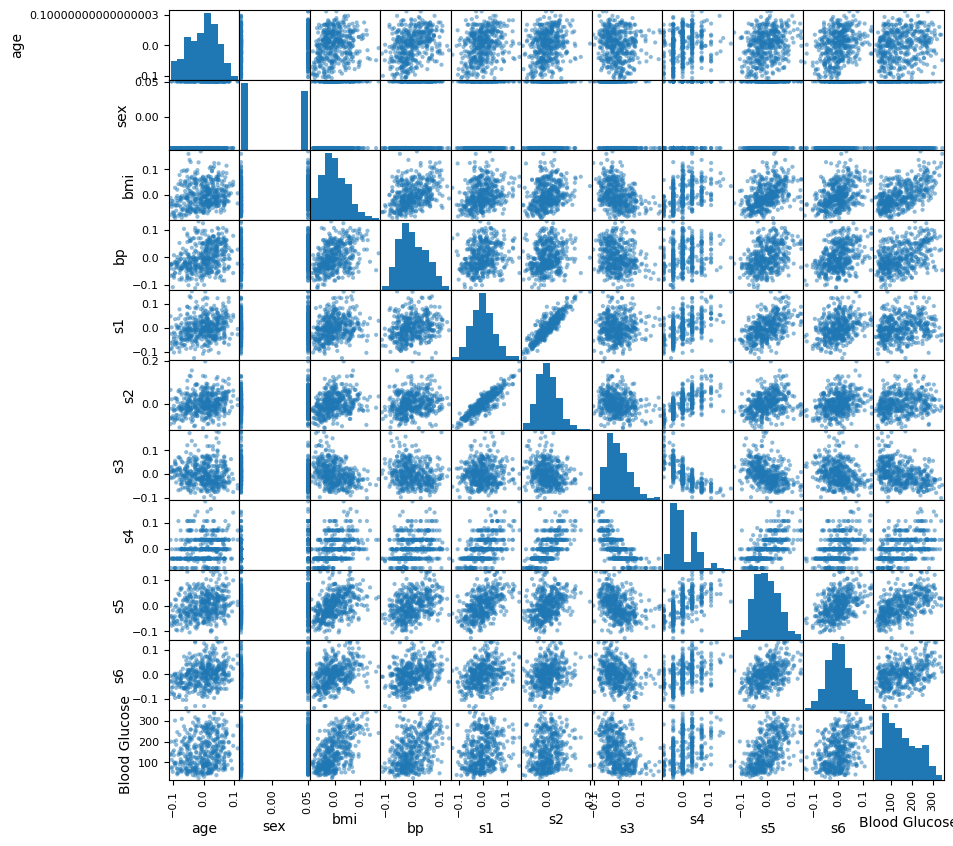

In [17]:
pd.plotting.scatter_matrix(dataset, figsize=(10,10))
plt.show()

## Analysing the Correlated features

Text(0.5, 0, 'bmi')

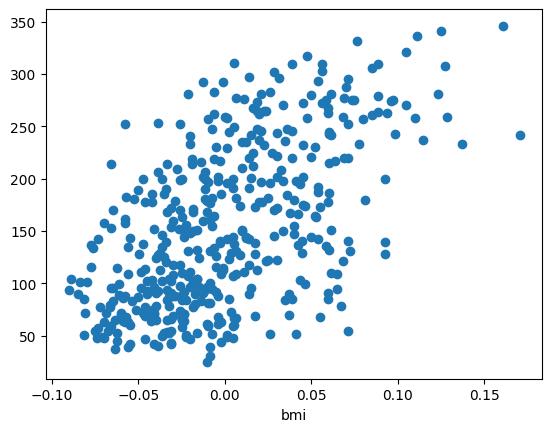

In [18]:
plt.scatter(dataset['bmi'],dataset['Blood Glucose'])
plt.xlabel('bmi')

In [19]:
## Independent and dependent features
X=dataset.iloc[:,:-1]
y=dataset.iloc[:,-1]

In [20]:
X.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [21]:
y

0      151.0
1       75.0
2      141.0
3      206.0
4      135.0
       ...  
437    178.0
438    104.0
439    132.0
440    220.0
441     57.0
Name: Blood Glucose, Length: 442, dtype: float64

In [22]:
## Train-test split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=41)

In [23]:
X_train

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491
348,0.030811,-0.044642,-0.020218,-0.005670,-0.004321,-0.029497,0.078093,-0.039493,-0.010903,-0.001078
214,0.030811,-0.044642,-0.033151,-0.022885,-0.046975,-0.081167,0.103865,-0.076395,-0.039809,-0.054925
265,-0.034575,0.050680,-0.025607,-0.017135,0.001183,-0.002880,0.008142,-0.015508,0.014821,0.040343
197,0.048974,0.050680,0.003494,0.070072,-0.008449,0.013404,-0.054446,0.034309,0.013317,0.036201
...,...,...,...,...,...,...,...,...,...,...
243,0.016281,0.050680,-0.046085,0.011544,-0.033216,-0.016032,-0.010266,-0.002592,-0.043984,-0.042499
321,0.096197,-0.044642,0.051996,0.079265,0.054845,0.036577,-0.076536,0.141322,0.098648,0.061054
80,0.070769,-0.044642,0.012117,0.042529,0.071357,0.053487,0.052322,-0.002592,0.025395,-0.005220
396,-0.085430,0.050680,-0.030996,-0.022885,-0.063487,-0.054236,0.019187,-0.039493,-0.096435,-0.034215


In [24]:
X_test

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
249,-0.012780,-0.044642,0.060618,0.052858,0.047965,0.029375,-0.017629,0.034309,0.070207,0.007207
291,0.074401,-0.044642,0.018584,0.063187,0.061725,0.042840,0.008142,-0.002592,0.058038,-0.059067
239,0.023546,-0.044642,0.019662,-0.012556,0.083740,0.038769,0.063367,-0.002592,0.066051,0.048628
152,-0.034575,0.050680,-0.000817,0.070072,0.039710,0.066952,-0.065491,0.108111,0.026717,0.073480
385,0.023546,0.050680,-0.019140,0.049415,-0.063487,-0.061125,0.004460,-0.039493,-0.025953,-0.013504
...,...,...,...,...,...,...,...,...,...,...
318,0.088931,-0.044642,0.006728,0.025315,0.030078,0.008707,0.063367,-0.039493,0.009434,0.032059
64,0.067136,0.050680,-0.025607,-0.040099,-0.063487,-0.059873,-0.002903,-0.039493,-0.019198,0.011349
327,0.074401,-0.044642,0.114509,0.028758,0.024574,0.024991,0.019187,-0.002592,-0.000612,-0.005220
140,0.041708,0.050680,0.014272,0.042529,-0.030464,-0.001314,-0.043401,-0.002592,-0.033246,0.015491


In [25]:
y_test

249    215.0
291    248.0
239    262.0
152    292.0
385    219.0
       ...  
318    109.0
64      71.0
327    237.0
140    118.0
58     170.0
Name: Blood Glucose, Length: 133, dtype: float64

In [26]:
## Standardising the datset
from sklearn.preprocessing import StandardScaler
scalar=StandardScaler()


In [27]:
X_train=scalar.fit_transform(X_train)

In [28]:
X_test=scalar.transform(X_test)

In [30]:
import pickle
pickle.dump(scalar,open('scaling.pkl','wb'))

In [29]:
X_train

array([[ 0.88307853,  1.07043605, -0.3202872 , ..., -0.23138617,
        -0.98074843,  0.34533474],
       [ 0.65486169, -0.93419873, -0.41021791, ..., -0.83837306,
        -0.19602988,  0.01030041],
       [ 0.65486169, -0.93419873, -0.68001004, ..., -1.62666773,
        -0.82646883, -1.07856117],
       ...,
       [ 1.49165677, -0.93419873,  0.26426241, ..., -0.0500784 ,
         0.59564715, -0.07345817],
       [-1.77945125,  1.07043605, -0.63504468, ..., -0.83837306,
        -2.06150091, -0.65976826],
       [-0.41015022, -0.93419873, -1.12966358, ..., -0.83837306,
        -1.57420799, -0.07345817]], shape=(309, 10))

## Model training

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
regression=LinearRegression()

In [ ]:
regression.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [ ]:
## print the coefficients and the intercept
print(regression.coef_)

[ -3.06951198 -12.57179248  24.75008946   9.1186459  -55.96629806
  38.55105927   8.32427833   6.31010546  43.78630478   8.55814982]


In [ ]:
print(regression.intercept_)

150.2588996763754


In [ ]:
## on which parameters the model has been trained
regression.get_params()

{'copy_X': True,
 'fit_intercept': True,
 'n_jobs': None,
 'positive': False,
 'tol': 1e-06}

In [ ]:
## Prediction with Test Data
reg_pred=regression.predict(X_test)

In [ ]:
reg_pred

array([241.45646454, 187.18560342, 182.48465984, 201.97425497,
       131.63372732, 144.19468425, 154.68012221, 127.15631625,
       137.20770241,  68.96454412,  56.93712039, 150.79569699,
       183.10521558, 174.46128574, 179.55821707, 163.36893823,
       253.265398  , 230.79200146, 197.64004368, 175.1415958 ,
       124.61352395, 157.72669225,  50.84539509, 122.20749502,
       151.49166309, 169.11122194, 159.16556523, 231.64501233,
       221.09652114, 194.30295332, 197.79165549, 101.69030086,
        34.48493678, 135.26899568, 150.94068236,  88.47289111,
       164.34449894, 258.16384503,  45.4736662 ,  41.00308898,
       119.89097968,  98.81559898, 209.31687211, 242.80026105,
        72.51488018, 206.24700705, 204.86687018, 113.31703515,
       125.64758324, 109.42159461, 211.83576382, 195.92778193,
        82.9983693 , 204.38100594, 112.63038624, 153.78732049,
       109.40885815, 251.4068729 , 192.8979034 , 229.9132983 ,
       144.32350122, 150.61690574, 193.62886206, 176.63

## Assumptions

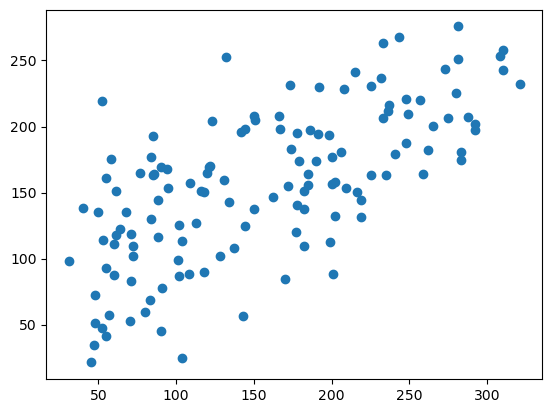

In [ ]:
## plot a scatter plot for the prediction
plt.scatter(y_test,reg_pred)

In [ ]:
## prediction with residuals
residuals=y_test-reg_pred
residuals

249   -26.456465
291    60.814397
239    79.515340
152    90.025745
385    87.366273
         ...    
318   -48.578371
64    -47.802315
327    20.943097
140   -32.278275
58     85.427774
Name: Blood Glucose, Length: 133, dtype: float64

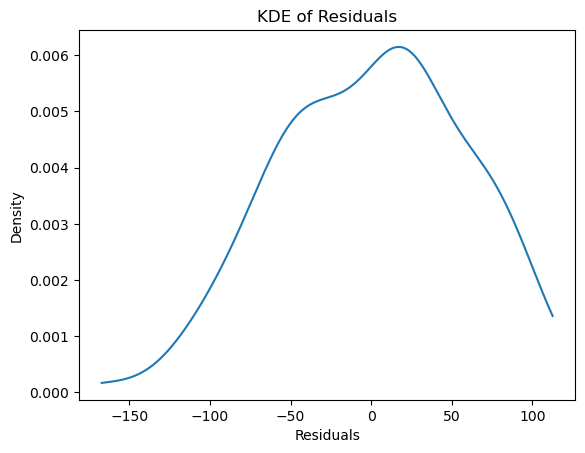

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

density = gaussian_kde(residuals)
x = np.linspace(min(residuals), max(residuals), 1000)

plt.plot(x, density(x))
plt.xlabel("Residuals")
plt.ylabel("Density")
plt.title("KDE of Residuals")
plt.show()

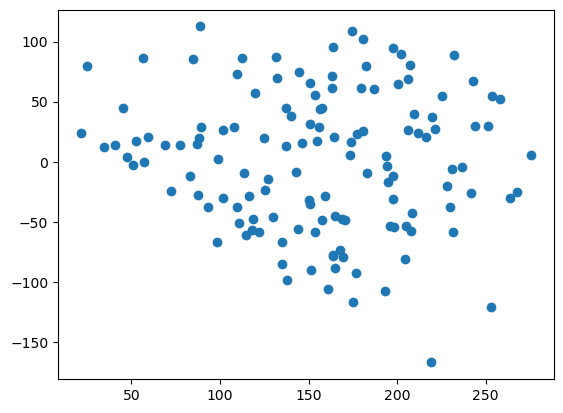

In [ ]:
## Scatter plot with respect to predictions and residuals
plt.scatter(reg_pred,residuals)

In [ ]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

print(mean_absolute_error(y_test,reg_pred))
print(mean_squared_error(y_test,reg_pred))
print(np.sqrt(mean_squared_error(y_test,reg_pred)))

47.560348830442976
3271.99012257962
57.201312245259025


## R square and adjusted R square

Formula 
R^2=1- SSR/SST

In [ ]:
from sklearn.metrics import r2_score
score=r2_score(y_test,reg_pred)
print(score)

0.45773113516817343


In [ ]:
1-(1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)


0.41328286755900734

## New Data Prediction

In [ ]:
boston.data[0].reshape(1,-1)

array([[ 0.03807591,  0.05068012,  0.06169621,  0.02187239, -0.0442235 ,
        -0.03482076, -0.04340085, -0.00259226,  0.01990749, -0.01764613]])

In [ ]:
x=scalar.transform(X.iloc[[437]])
x

array([[ 0.88307853,  1.07043605,  0.42164115,  1.28182356, -0.12072005,
        -0.0735689 , -0.62832216, -0.0500784 ,  0.72209281,  0.17781757]])

In [ ]:
regression.predict(x)


array([187.72846282])

## Pickling the Model file for Deployment

In [ ]:
import pickle

In [ ]:
pickle.dump(regression,open('regmodel.pkl','wb'))

In [ ]:
loaded_model = pickle.load(open('regmodel.pkl', 'rb'))

In [ ]:
loaded_model.predict(scalar.transform(X.iloc[[437]]))

array([187.72846282])